In [78]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database


random.seed(42)
np.random.seed(42)

human_proteome = pd.read_csv("../data/human_proteome.gz", sep=",")
human_proteome["trivname"] = human_proteome["trivname"].apply(lambda x: x.split("_")[0])

database_dict = get_database(human_proteome, key_col="trivname", value_col="seq")

In [79]:
datamatrix = pd.read_csv("../data/human_data.csv")

pnet = PeptideNetwork(
    datamatrix=datamatrix,
    protein_database=database_dict,
)

Reading peptides...


In [80]:
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)

In [81]:
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=3)
clusters.reindex()
mapping = clusters.get_mapping(database_dict)

Merged 434 clusters

Removed 0 clusters
Removed 5542 clusters
Removed 2143 clusters


In [82]:
from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/human_design.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
datamatrix = fm.get_normalized_dm()

In [91]:
topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
    .set_index("Cluster")
)


Mean of empty slice


Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


<Figure size 500x400 with 0 Axes>

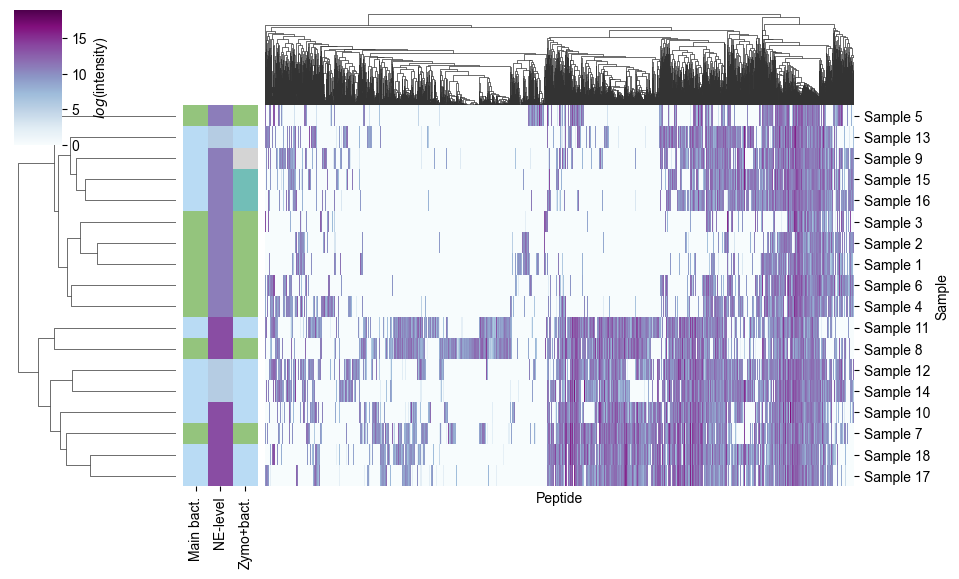

In [95]:
from pepnets.palette import human_group_palette
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pepnets.palette import *

plt.figure(figsize=(5, 4))

magma = sns.color_palette("BuPu")
new_group_palette = {
    "Low NE": magma[3],
    "Medium NE": magma[1],
    "High NE": magma[4],
    "Group 4": magma[5],
}

group1 = [10, 17, 18, 11, 7, 8]
group2 = [13, 14, 12]
group3 = [4, 9, 1, 2, 16, 6, 5, 3, 15]


def assign_new_group(v):
    v = int(v.split(" ")[-1])
    if v in group1:
        return "High NE"
    elif v in group2:
        return "Medium NE"
    elif v in group3:
        return "Low NE"



design["new_group"] = [assign_new_group(x) for x in design["sample"]]
design.sort_values("new_group", inplace=True)

samples = [str(x) for x in design["sample"].tolist()]
df = topn[samples]
new_group = pd.Series(design["new_group"])
old_group = pd.Series(design["group"])
bact = pd.Series(design["bacteria"])

day = pd.Series(design["Day"])

row_colors_new_group = new_group.map(new_group_palette)
row_colors_old_group = old_group.map(human_group_palette)
row_colors_bacteria = bact.map(human_group_palette)

row_colors = pd.DataFrame(
    {
        "bacteria": row_colors_bacteria,
        "new_group": row_colors_new_group,
        "old_group": row_colors_old_group,
    }
)

df.fillna(0, inplace=True)
g = sns.clustermap(
    df[samples].T,
    row_cluster=True,
    col_cluster=True,
    metric="euclidean",
    cbar_kws={"label": r"$log$(intensity)"},
    cmap="BuPu",
    vmin=0,
    row_colors=row_colors.values.T,
    figsize=(9.5, 7.5),
)

g.ax_heatmap.set_xlabel("Peptide")
g.ax_heatmap.set_ylabel("Sample")
g.ax_heatmap.set_xticks([])
g.ax_row_colors.set_xticks(
    [0.5, 1.5, 2.5], ["Main bact.", "NE-level", "Zymo+bact."], rotation=90
)

df.to_csv("source_data/6c.csv")
plt.savefig("figures/main_figures/6c.png", dpi=600, bbox_inches="tight")

In [97]:
de_design

,sample,group
17,Sample 18,1
10,Sample 11,1
9,Sample 10,1
16,Sample 17,1
6,Sample 7,1
7,Sample 8,1
8,Sample 9,1
5,Sample 6,2
1,Sample 2,2
2,Sample 3,2


In [99]:
de_design = design.copy()
de_design["group"] = [
    (
        1
        if int(sample.split("Sample ")[-1])
        in [13, 9, 16, 15, 11, 8, 12, 14, 10, 7, 18, 17]
        else 2
    )
    for sample in design["sample"]
]
de_design = de_design[["sample", "group"]]

from dpks import QuantMatrix
topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
)

topn_de = topn.reset_index().fillna(0.01)
qm = QuantMatrix(topn_de, de_design)
qm.compare(
    method="linregress",
    min_samples_per_group=3,
    level="Cluster",
    comparisons=[(1, 2)],
    multiple_testing_correction_method="fdr_tsbh",
)

Mean of empty slice


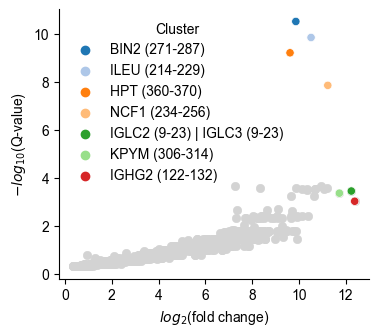

In [100]:
compared_data = qm.to_df()
compared_data = compared_data[compared_data["Group2Mean"] == 0.01]
plot_data = compared_data.groupby("Cluster", as_index=False).mean(numeric_only=True)

plot_data.sort_values("-Log10CorrectedPValue1-2", ascending=False, inplace=True)
plt.figure(figsize=(4, 3.5))
g = sns.scatterplot(
    plot_data[plot_data["-Log10CorrectedPValue1-2"] < 6],
    y="-Log10CorrectedPValue1-2",
    x="Log2FoldChange1-2",
    color="lightgray",
    edgecolor=None,
)
g = sns.scatterplot(
    plot_data[
        (plot_data["-Log10CorrectedPValue1-2"] > 7)
        | (plot_data["Log2FoldChange1-2"] > 11.7)
    ],
    y="-Log10CorrectedPValue1-2",
    x="Log2FoldChange1-2",
    hue="Cluster",
    palette="tab20",
)
g.legend().remove()

g.legend().remove()

g.legend().remove()
g.legend(title="Cluster", frameon=False)
sns.despine()
plt.xlabel(r"$log_2$(fold change)")
plt.ylabel(r"$-log_{10}$(Q-value)")
plot_data.to_csv("source_data/6e.csv")
plt.savefig("figures/main_figures/6e.svg", bbox_inches="tight")

Mean of empty slice


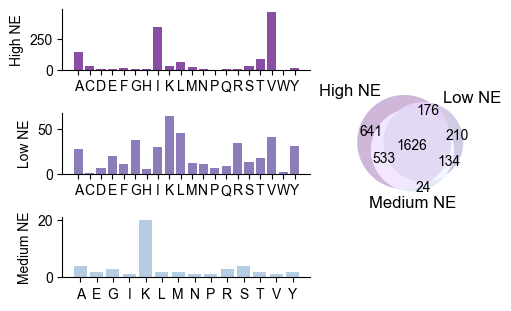

In [101]:
from matplotlib_venn import venn3

topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)
groups = design["new_group"].unique().tolist()

venn_dict = {}

all_clusters = clusters.to_df(database_dict)

for group in groups:
    group_values = topn[design[design["new_group"] == group]["sample"]].T

    means = group_values.mean(axis=0)
    means = means[means > 0]
    venn_dict[group] = set(means.index.values.tolist())


fig, axs = plt.subplot_mosaic(
    [
        [
            "upper left",
            "right",
        ],
        ["middle left", "right"],
        ["lower left", "right"],
    ],
    figsize=(5, 3),
    layout="constrained",
    width_ratios=[2, 1],
)

venn3(
    venn_dict.values(),
    venn_dict.keys(),
    ax=axs["right"],
    set_colors=[new_group_palette[group] for group in groups],
)

counts = []
for ax, group in zip(
    [axs["upper left"], axs["middle left"], axs["lower left"]], groups
):
    pa = venn_dict[group].copy()
    testing = groups.copy()
    testing.remove(group)
    for test in testing:
        for cluster in venn_dict[test]:
            if cluster in pa:
                pa.remove(cluster)

    unique_clusters = all_clusters[all_clusters["ID"].isin(pa)].copy()
    unique_clusters["count"] = 1
    countN = unique_clusters.groupby("Np1").sum(numeric_only=True)["count"]
    countC = unique_clusters.groupby("Cp1").sum(numeric_only=True)["count"]
    count = pd.DataFrame({"C": countC, "N": countN}).fillna(0)
    count["tot"] = count["C"] + count["N"]
    count["NE"] = [group] * len(count.index)
    counts.append(count)
    ax.bar(x=count.index, height=count["tot"], color=new_group_palette[group])
    sns.despine(ax=ax)
    ax.set_ylabel(group)
pd.concat(counts).to_csv("source_data/6h.csv")
plt.savefig("figures/main_figures/6h.svg", bbox_inches="tight")

In [13]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database

random.seed(42)
np.random.seed(42)

sus_scrofa = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
sus_scrofa["Entry Name"] = sus_scrofa["Entry Name"].apply(lambda x: x.split("_")[0])
database_dict = get_database(sus_scrofa, key_col="Entry Name", value_col="Sequence")

datamatrix = pd.read_csv("../data/data.csv")

pnet = PeptideNetwork(datamatrix=datamatrix, protein_database=database_dict)
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=5)
clusters.reindex()

design = pd.read_csv("../data/design.csv")
pig_fm = FeatureMatrix(pnet.datamatrix, design, clusters)

Reading peptides...
Merged 41 clusters

Removed 0 clusters
Removed 857 clusters
Removed 303 clusters
Removed 151 clusters
Removed 105 clusters


In [14]:
import pandas as pd
from pepnets.LogoPlot import LogoPlot
from pepnets.util import get_database

pig_db = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
pig_db = get_database(pig_db, key_col="Entry Name", value_col="Sequence")
pig_dm = pig_fm.datamatrix
pig_dm["Cluster"] = [str(x) + "_pig" for x in pig_dm["Cluster"]]
pig_design = pd.read_csv("../data/design_w_accidental.csv")
pig_dm["Protein"] = pig_dm["Protein"].apply(lambda x: str(x) + "_PIG")


human_dm = fm.datamatrix.copy()
human_dm["Cluster"] = [str(x) + "_human" for x in human_dm["Cluster"]]
human_design = pd.read_csv("../data/human_design.csv")
human_dm["Protein"] = human_dm["Protein"].apply(lambda x: str(x) + "_HUMAN")
human_db = pd.read_csv("../data/human_proteome.gz", sep=",")
human_db = get_database(human_db, key_col="trivname", value_col="seq")


db = {}
db.update(human_db)
db.update(pig_db)
dm = pd.concat([human_dm, pig_dm])
design = pd.concat([human_design, pig_design])
lp = LogoPlot(dm, db, entity="Cluster")


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

background_samples = pig_design[pig_design["group"] == "Ctrl"]["sample"].tolist()
test_samples = [s for s in human_design["sample"]]
X = {}
for i, sample in enumerate(test_samples):
    sample_name = [
        str(x)
        for x in zip(
            design[design["sample"] == sample]["group"].tolist(),
            design[design["sample"] == sample]["Trial person"].tolist(),
            design[design["sample"] == sample]["Day"].tolist(),
            design[design["sample"] == sample]["Wound"].tolist(),
        )
    ]
    sample = [str(sample)]

    height = lp.get_letter_heights(sample, background_samples)
    X[sample[0]] = np.reshape(height.values, (height.shape[0] * height.shape[1],))

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.


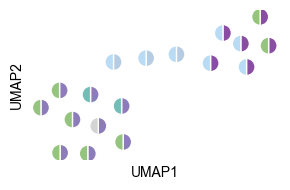

In [64]:
from umap import UMAP
from matplotlib.markers import MarkerStyle

p = pd.DataFrame(X)

X_reduced = UMAP(random_state=42).fit_transform(p.T)

magma = sns.color_palette("BuPu")
new_group_palette = {
    "Low NE": magma[3],
    "Medium NE": magma[1],
    "High NE": magma[4],
    "Group 4": magma[5],
}
group1 = [10, 17, 18, 11, 7, 8]
group2 = [13, 14, 12]
group3 = [4, 9, 1, 2, 16, 6, 5, 3, 15]


def assign_new_group(v):
    v = int(v.split(" ")[-1])
    if v in group1:
        return "High NE"
    elif v in group2:
        return "Medium NE"
    elif v in group3:
        return "Low NE"


plot_df = pd.DataFrame(X_reduced, columns=["UMAP1", "UMAP2"])
plot_df["group"] = human_design["group"]
plot_df["Trial person"] = human_design["Trial person"]
plot_df["sample"] = human_design["sample"].apply(lambda x: x.split(" ")[-1])
plot_df["new_group"] = [assign_new_group(x) for x in human_design["sample"]]
plot_df = plot_df.sort_values("new_group")


fig = plt.figure(figsize=(3,2))
g = sns.scatterplot(
    plot_df, x="UMAP1", y="UMAP2", hue="new_group", palette=new_group_palette, s=150, marker=MarkerStyle("o", fillstyle="right")
)
g = sns.scatterplot(
    plot_df, x="UMAP1", y="UMAP2", hue="group", palette=human_group_palette, s=150, marker=MarkerStyle("o", fillstyle="left")
)
g.legend().remove()
sns.despine(left=True, right=True, top=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plot_df.to_csv("source_data/6g.csv")
plt.savefig("figures/main_figures/6g.svg", bbox_inches="tight")

Low NE
Medium NE
High NE


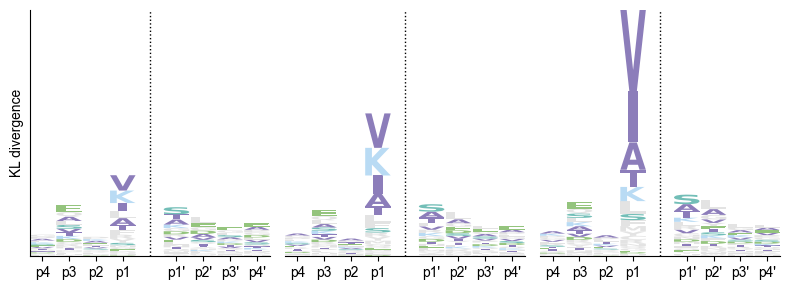

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

dm = pd.concat([human_dm, pig_dm])
design = pd.concat([human_design, pig_design])
lp = LogoPlot(dm, db, entity="Cluster")

group1 = [10, 17, 18, 11, 7, 8]
group2 = [13, 14, 12, 15]
group3 = [4, 9, 1, 2, 16, 6, 5, 3]


def assign_new_group(v):
    v = int(v.split(" ")[-1])
    if v in group1:
        return "High NE"
    elif v in group2:
        return "Medium NE"
    elif v in group3:
        return "Low NE"
    else:
        return "Group 4"


human_design["new_group"] = [assign_new_group(x) for x in human_design["sample"]]
lp = LogoPlot(dm, db)
heights = []
groups = ["Low NE", "Medium NE", "High NE"]
background_samples = pig_design[pig_design["group"] == "Ctrl"]["sample"].tolist()
fig, axs = plt.subplots(1, len(groups), figsize=(8, 3), sharey=True)
max_y = 0
for i, test_group in enumerate(groups):
    test_samples = human_design[human_design["new_group"] == test_group][
        "sample"
    ].tolist()
    print(test_group)

    height = lp.get_letter_heights(test_samples, background_samples)

    lp.plot(height, ax=axs[i])
    
    if i==0:
        sns.despine(ax=axs[i])
        axs[i].set_ylabel("KL divergence")
    else:
        sns.despine(ax=axs[i], left=True, right=True, top=True)
        axs[i].set_yticks([])
        axs[i].set_ylabel("")
    axs[i].set_xticks(
        [-4, -3, -2, -1, 1, 2, 3, 4],
        ["p4", "p3", "p2", "p1", "p1'", "p2'", "p3'", "p4'"],
    )
    axs[i].axvline(0, color="k", linewidth=1, linestyle=":")
   
    max_y = max(max_y, max(height.sum(axis=1).max(), height.sum(axis=1).max()))
    height["group"] = [group] * len(height)
    heights.append(height)

for ax in axs.ravel():
    ax.set_ylim(0, max_y)
    continue

plt.tight_layout()
pd.concat(heights).to_csv("source_data/6f.csv")
plt.savefig("figures/main_figures/6f.svg", bbox_inches="tight")

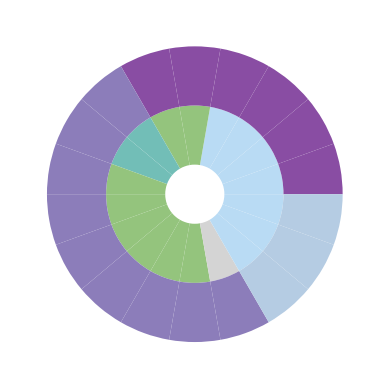

In [76]:
import pandas as pd

design = pd.read_csv("../data/human_design.csv", sep=",")
samples = [str(x) for x in design["sample"]]
new_group_palette = {
    "Low NE": magma[3],
    "Medium NE": magma[1],
    "High NE": magma[4],
    "Group 4": magma[5],
}

group1 = [10, 17, 18, 11, 7, 8]
group2 = [13, 14, 12]
group3 = [4, 9, 1, 2, 16, 6, 5, 3, 15]


def assign_new_group(v):
    v = int(v.split(" ")[-1])
    if v in group1:
        return "High NE"
    elif v in group2:
        return "Medium NE"
    elif v in group3:
        return "Low NE"



design["new_group"] = [assign_new_group(x) for x in design["sample"]]

design["count"] = 1

design = design.sort_values("new_group")


fig, ax = plt.subplots()
ax.pie(
    design["count"],
    radius=1 - 0.4,
    colors=design["group"].map(human_group_palette),
    wedgeprops=dict(width=0.4, edgecolor=None),
)
ax.pie(
    design["count"],
    radius=1,
    colors=design["new_group"].map(new_group_palette),
    wedgeprops=dict(width=0.4, edgecolor=None),
)
design.to_csv("source_data/6d.csv")
plt.savefig("figures/main_figures/6d.svg", bbox_inches="tight")